# Quantitative Analysis of Single-Molecule DNA Mechanics

## Project Overview

This project analyzes single-molecule magnetic-tweezers data to examine how cytosine methylation affects DNA mechanical properties.

Two representative experimental datasets are compared:

* **cPCR:** control PCR-generated DNA produced using standard dCTP.
* **mPCR:** methylated PCR-generated DNA produced by substituting 5-methyl-dCTP (5-m-dCTP) for standard dCTP during PCR.

The force-extension measurements were experimentally acquired and initially processed in Excel. This notebook provides a reproducible Python workflow for importing the processed data, validating variable definitions, visualizing force-extension behavior, fitting a worm-like chain (WLC)-derived linear model, and estimating DNA persistence length.

## Analytical Workflow

1. Import processed force-extension datasets.
2. Validate data structure and variable definitions.
3. Perform basic data-quality assessment.
4. Visualize force-extension relationships.
5. Fit a WLC-derived linear model.
6. Estimate persistence length for control and methylated DNA.
7. Compare DNA mechanical behavior between the two representative experiments.
8. Explore additional computational modeling approaches.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

## Source Analysis

This portfolio notebook builds a reproducible Python analysis from two representative single-molecule DNA force–extension datasets generated during a previously published experimental study.

The original magnetic-tweezers measurements were experimentally acquired and initially processed in Excel. The processed datasets are imported directly from the archived GitHub repository and analyzed here using a streamlined Python workflow.

The analysis focuses on comparing the mechanical behavior of control and methylated DNA using a worm-like chain (WLC)-derived model and persistence-length estimation.


## 1. Force–Extension Dataset

The archived CSV files contain force-extension measurements that were initially processed in Excel.

Two variables are provided:

* **`deltaZ/L`:** normalized DNA extension (\(Z/L\))
* **`1/F`:** a historical column label corresponding to \(F^{-1/2}=1/\sqrt{F}\)

The second variable is renamed in the analysis to `inv_sqrt_force` so that its computational name reflects the actual transformation.

The control and methylated datasets contain 267 and 239 observations, respectively.


In [3]:
# Load processed force-extension datasets directly from the GitHub repository

base_url = "https://raw.githubusercontent.com/tzaichuk/final_project/master/archive/data/"

cPCR = pd.read_csv(base_url + "cPCR.csv")
mPCR = pd.read_csv(base_url + "mPCR.csv")

print("Control DNA (cPCR):", cPCR.shape)
print("Methylated DNA (mPCR):", mPCR.shape)

display(cPCR.head())
display(mPCR.head())

Control DNA (cPCR): (267, 2)
Methylated DNA (mPCR): (239, 2)


,deltaZ/L,1/F
0,0.952355,0.451676
1,0.923634,0.509886
2,0.899607,0.653958
3,0.915279,0.851072
4,0.895834,0.956380


,deltaZ/L,1/F
0,0.970813,0.597860
1,0.947911,0.583460
2,0.932762,0.715491
3,0.904442,0.842840
4,0.883281,0.938853


### Data validation and variable naming

The archived CSV files contain processed force-extension data rather than the original raw measurements. Each dataset contains normalized extension (`deltaZ/L`) and a derived force variable originally labeled `1/F`.

Review of the original Excel analysis and the published methodology showed that this derived variable corresponds to the inverse square root of force,

$$
F^{-1/2} = \frac{1}{\sqrt{F}},
$$

rather than \(1/F\).

Because the original force measurements are not retained in these processed CSV files, the transformation cannot be independently recalculated here. The column is therefore renamed `inv_sqrt_force` to accurately describe the quantity used in the original analysis.


In [4]:
# Rename archived variables to clearer portfolio-friendly names

cPCR = cPCR.rename(columns={
    "deltaZ/L": "normalized_extension",
    "1/F": "inv_sqrt_force"
})

mPCR = mPCR.rename(columns={
    "deltaZ/L": "normalized_extension",
    "1/F": "inv_sqrt_force"
})

print("Control DNA columns:", cPCR.columns.tolist())
print("Methylated DNA columns:", mPCR.columns.tolist())

display(cPCR.head())
display(mPCR.head())

Control DNA columns: ['normalized_extension', 'inv_sqrt_force']
Methylated DNA columns: ['normalized_extension', 'inv_sqrt_force']


,normalized_extension,inv_sqrt_force
0,0.952355,0.451676
1,0.923634,0.509886
2,0.899607,0.653958
3,0.915279,0.851072
4,0.895834,0.956380


,normalized_extension,inv_sqrt_force
0,0.970813,0.597860
1,0.947911,0.583460
2,0.932762,0.715491
3,0.904442,0.842840
4,0.883281,0.938853


## 2. Data Quality Assessment

Before modeling, the datasets were evaluated for missing values, duplicate observations, numerical ranges, and basic descriptive statistics. This step helps identify potential data-quality issues and provides context for subsequent force–extension analysis.

In [5]:
# Basic data-quality checks

for name, df in {
    "Control DNA": cPCR,
    "Methylated DNA": mPCR
}.items():

    print(f"\n{name}")
    print(f"Rows: {len(df)}")
    print(f"Missing values: {df.isna().sum().sum()}")
    print(f"Duplicate rows: {df.duplicated().sum()}")

    display(df.describe())


Control DNA
Rows: 267
Missing values: 0
Duplicate rows: 12


,normalized_extension,inv_sqrt_force
count,267.000000,267.000000
mean,0.833406,1.449675
std,0.088379,0.633613
min,0.612765,0.306780
25%,0.781308,0.965770
50%,0.846449,1.359695
75%,0.902923,1.833748
max,0.970337,3.123475



Methylated DNA
Rows: 239
Missing values: 0
Duplicate rows: 11


,normalized_extension,inv_sqrt_force
count,239.000000,239.000000
mean,0.812561,1.272351
std,0.089147,0.484963
min,0.600563,0.383813
25%,0.755227,0.921109
50%,0.821131,1.225266
75%,0.880904,1.596794
max,0.973232,2.736903


In [6]:
# Inspect duplicate observations without modifying the datasets

for name, df in {
    "Control DNA": cPCR,
    "Methylated DNA": mPCR
}.items():

    duplicates = df[
        df.duplicated(
            subset=["normalized_extension", "inv_sqrt_force"],
            keep=False
        )
    ].sort_values(
        ["inv_sqrt_force", "normalized_extension"]
    )

    print(f"\n{name}")
    print(f"Rows involved in duplicate pairs/groups: {len(duplicates)}")
    print(
        "Number of extra duplicate rows:",
        df.duplicated(
            subset=["normalized_extension", "inv_sqrt_force"]
        ).sum()
    )

    display(duplicates)


Control DNA
Rows involved in duplicate pairs/groups: 24
Number of extra duplicate rows: 12


,normalized_extension,inv_sqrt_force
102,0.949658,0.448692
244,0.949658,0.448692
103,0.906813,0.503825
245,0.906813,0.503825
104,0.928771,0.679659
246,0.928771,0.679659
105,0.869072,0.821579
247,0.869072,0.821579
106,0.847605,0.916814
248,0.847605,0.916814



Methylated DNA
Rows involved in duplicate pairs/groups: 22
Number of extra duplicate rows: 11


,normalized_extension,inv_sqrt_force
24,0.861421,0.992437
35,0.861421,0.992437
25,0.881351,1.057920
36,0.881351,1.057920
26,0.907983,1.099831
37,0.907983,1.099831
27,0.871111,1.129097
38,0.871111,1.129097
28,0.835586,1.225266
39,0.835586,1.225266


### Duplicate-Observation Assessment

Inspection of exact duplicate observations identified 12 duplicated rows in the control dataset and 11 in the methylated dataset. The duplicates occur as repeated consecutive sequences of force–extension coordinates rather than as isolated coincident values, suggesting that they may have been introduced during preparation of the archived processed datasets.

For the subsequent analysis, one copy of each exact duplicated force–extension coordinate is retained. The original imported datasets remain unchanged, and cleaned analytical datasets are created separately.


In [7]:
# Create cleaned analytical datasets while preserving the imported data

cPCR_clean = (
    cPCR[
        ["normalized_extension", "inv_sqrt_force"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

mPCR_clean = (
    mPCR[
        ["normalized_extension", "inv_sqrt_force"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    f"Control DNA: {len(cPCR)} → {len(cPCR_clean)} observations"
)

print(
    f"Methylated DNA: {len(mPCR)} → {len(mPCR_clean)} observations"
)

Control DNA: 267 → 255 observations
Methylated DNA: 239 → 228 observations


## 3. Worm-Like Chain Analysis

DNA force–extension behavior can be described using the worm-like chain (WLC) model. In the low-to-intermediate force regime, normalized extension can be approximated as

$$
\frac{Z}{L}
=
1-\sqrt{\frac{k_BT}{4A}}F^{-1/2},
$$

where \(Z/L\) is normalized extension, \(F\) is applied force, \(A\) is persistence length, \(k_B\) is the Boltzmann constant, and \(T\) is absolute temperature.

This form predicts an approximately linear relationship between normalized extension and \(F^{-1/2}\):

$$
\frac{Z}{L}=b_0+b_1F^{-1/2}.
$$

The regression slope is related to persistence length by

$$
A=\frac{k_BT}{4b_1^2}.
$$

Separate linear models are fitted to the representative control and methylated DNA datasets.


In [8]:
# Fit WLC-derived linear models to cleaned datasets

fit_control = linregress(
    cPCR_clean["inv_sqrt_force"],
    cPCR_clean["normalized_extension"]
)

fit_methylated = linregress(
    mPCR_clean["inv_sqrt_force"],
    mPCR_clean["normalized_extension"]
)

print("Control DNA")
print(f"  Slope:     {fit_control.slope:.6f}")
print(f"  Intercept: {fit_control.intercept:.6f}")
print(f"  R²:        {fit_control.rvalue**2:.4f}")

print("\nMethylated DNA")
print(f"  Slope:     {fit_methylated.slope:.6f}")
print(f"  Intercept: {fit_methylated.intercept:.6f}")
print(f"  R²:        {fit_methylated.rvalue**2:.4f}")

Control DNA
  Slope:     -0.129474
  Intercept: 1.022219
  R²:        0.8471

Methylated DNA
  Slope:     -0.164809
  Intercept: 1.020568
  R²:        0.8018


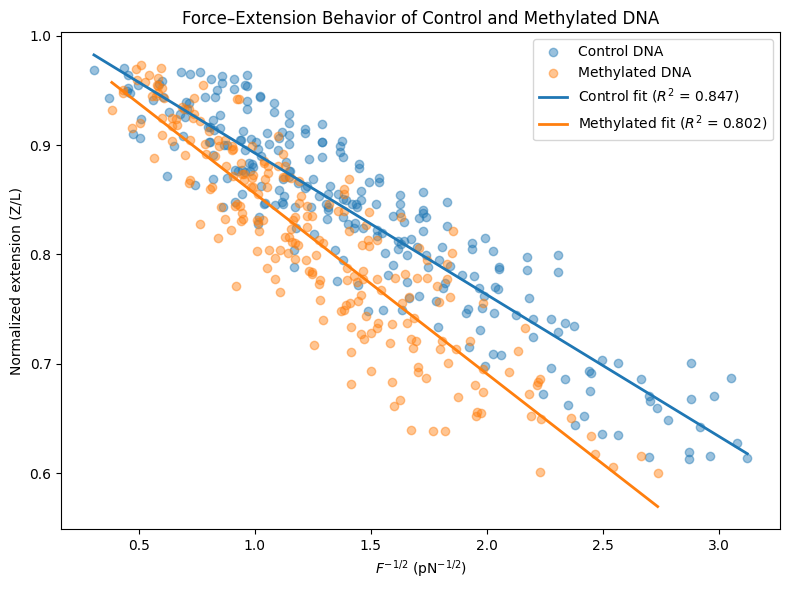

In [9]:
# Plot experimental data and WLC-derived linear fits

x_control = np.linspace(
    cPCR_clean["inv_sqrt_force"].min(),
    cPCR_clean["inv_sqrt_force"].max(),
    200
)

x_methylated = np.linspace(
    mPCR_clean["inv_sqrt_force"].min(),
    mPCR_clean["inv_sqrt_force"].max(),
    200
)

plt.figure(figsize=(8, 6))

plt.scatter(
    cPCR_clean["inv_sqrt_force"],
    cPCR_clean["normalized_extension"],
    alpha=0.45,
    label="Control DNA"
)

plt.scatter(
    mPCR_clean["inv_sqrt_force"],
    mPCR_clean["normalized_extension"],
    alpha=0.45,
    label="Methylated DNA"
)

plt.plot(
    x_control,
    fit_control.intercept + fit_control.slope * x_control,
    linewidth=2,
    label=f"Control fit ($R^2$ = {fit_control.rvalue**2:.3f})"
)

plt.plot(
    x_methylated,
    fit_methylated.intercept + fit_methylated.slope * x_methylated,
    linewidth=2,
    label=f"Methylated fit ($R^2$ = {fit_methylated.rvalue**2:.3f})"
)

plt.xlabel(r"$F^{-1/2}$ (pN$^{-1/2}$)")
plt.ylabel("Normalized extension (Z/L)")
plt.title("Force–Extension Behavior of Control and Methylated DNA")

plt.legend()
plt.tight_layout()

plt.savefig(
    "force_extension_wlc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Regression Interpretation

Both datasets show the approximately linear dependence of normalized DNA extension on \(F^{-1/2}\) expected from the low-to-intermediate-force approximation of the worm-like chain model.

The methylated DNA dataset has a more negative regression slope than the control dataset, indicating a change in DNA mechanical behavior consistent with increased flexibility. The fitted models explain approximately 85% of the variation in the control dataset and 80% in the methylated dataset.



## 4. Persistence Length Estimation

In the WLC-derived linear approximation,

$$
\frac{Z}{L}
=
1-\sqrt{\frac{k_BT}{4A}}F^{-1/2},
$$

the regression slope \(b_1\) is related to the persistence length \(A\) by

$$
A=\frac{k_BT}{4b_1^2}.
$$

Persistence length provides a quantitative measure of DNA bending stiffness: a larger value corresponds to a stiffer polymer, whereas a smaller value indicates greater flexibility.

Using \(k_BT = 4.114\ \text{pN}\cdot\text{nm}\) at approximately room temperature, persistence length is estimated separately for the representative control and methylated DNA experiments.


In [10]:
# Estimate persistence length from the fitted WLC slopes

kBT = 4.114  # pN·nm, approximately room temperature

A_control = kBT / (4 * fit_control.slope**2)
A_methylated = kBT / (4 * fit_methylated.slope**2)

relative_change = (
    (A_methylated - A_control) / A_control * 100
)

print("Estimated persistence length")
print(f"  Control DNA:    {A_control:.1f} nm")
print(f"  Methylated DNA: {A_methylated:.1f} nm")
print(f"\nRelative change after methylation: {relative_change:.1f}%")

Estimated persistence length
  Control DNA:    61.4 nm
  Methylated DNA: 37.9 nm

Relative change after methylation: -38.3%


In [11]:
# Summarize fitted model parameters and persistence-length estimates

results = pd.DataFrame({
    "Condition": ["Control DNA", "Methylated DNA"],
    "Observations": [len(cPCR_clean), len(mPCR_clean)],
    "Slope": [fit_control.slope, fit_methylated.slope],
    "Intercept": [fit_control.intercept, fit_methylated.intercept],
    "R_squared": [
        fit_control.rvalue**2,
        fit_methylated.rvalue**2
    ],
    "Persistence_length_nm": [
        A_control,
        A_methylated
    ]
})

results.round({
    "Slope": 4,
    "Intercept": 4,
    "R_squared": 3,
    "Persistence_length_nm": 1
})

,Condition,Observations,Slope,Intercept,R_squared,Persistence_length_nm
0,Control DNA,255,-0.1295,1.0222,0.847,61.4
1,Methylated DNA,228,-0.1648,1.0206,0.802,37.9


### Interpretation

The representative methylated DNA experiment shows a lower estimated persistence length than the control experiment (37.9 nm versus 61.4 nm), corresponding to a decrease of approximately 38%.

Because persistence length reflects polymer bending stiffness, the lower value indicates greater flexibility of the methylated DNA in these representative force–extension measurements.

These estimates are derived from the two processed datasets analyzed in this notebook. The associated publication used multiple independent experiments per condition for its aggregate statistical analysis; therefore, the values calculated here characterize these representative datasets rather than reproduce the publication-level estimates.



## 5. Model Diagnostics

Residual analysis was used to assess whether the linearized WLC approximation provides a reasonable description of the two representative datasets.

For each condition, residuals were calculated as the difference between observed normalized extension and the value predicted by the fitted linear model:

$$
\text{residual} = y_{\text{observed}} - y_{\text{predicted}}.
$$

A well-behaved linear model should produce residuals that are centered near zero without a strong systematic pattern across the fitted range.


In [12]:
# Calculate fitted values and residuals for cleaned datasets

cPCR_clean["predicted_extension"] = (
    fit_control.intercept
    + fit_control.slope * cPCR_clean["inv_sqrt_force"]
)

mPCR_clean["predicted_extension"] = (
    fit_methylated.intercept
    + fit_methylated.slope * mPCR_clean["inv_sqrt_force"]
)

cPCR_clean["residual"] = (
    cPCR_clean["normalized_extension"]
    - cPCR_clean["predicted_extension"]
)

mPCR_clean["residual"] = (
    mPCR_clean["normalized_extension"]
    - mPCR_clean["predicted_extension"]
)

print("Residual summary")

print("\nControl DNA")
print(cPCR_clean["residual"].describe())

print("\nMethylated DNA")
print(mPCR_clean["residual"].describe())

Residual summary

Control DNA
count    2.550000e+02
mean    -8.707632e-17
std      3.469710e-02
min     -8.176990e-02
25%     -2.256960e-02
50%     -3.882872e-04
75%      2.498333e-02
max      7.593026e-02
Name: residual, dtype: float64

Methylated DNA
count    2.280000e+02
mean    -1.266044e-17
std      4.038129e-02
min     -1.055599e-01
25%     -3.057130e-02
50%      3.521321e-03
75%      2.938107e-02
max      1.070827e-01
Name: residual, dtype: float64


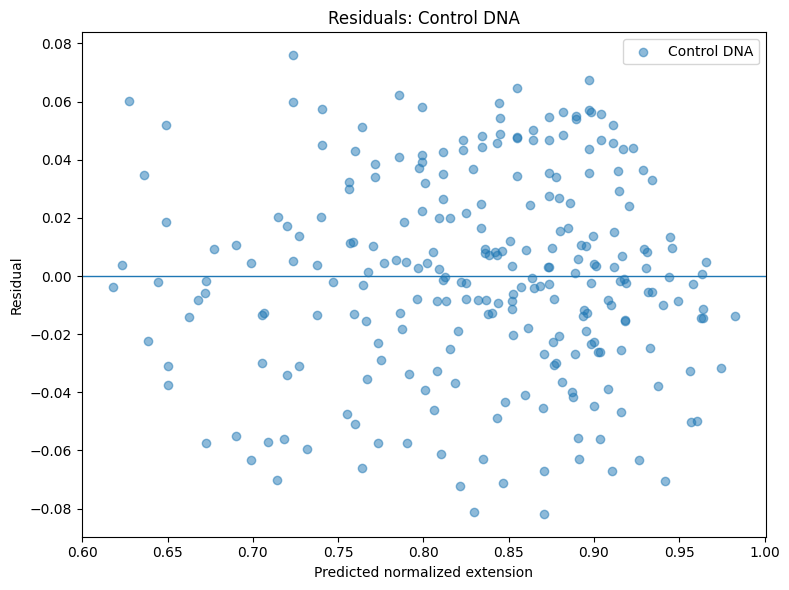

In [13]:
# Residual plots

plt.figure(figsize=(8, 6))

plt.scatter(
    cPCR_clean["predicted_extension"],
    cPCR_clean["residual"],
    alpha=0.5,
    label="Control DNA"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Predicted normalized extension")
plt.ylabel("Residual")
plt.title("Residuals: Control DNA")
plt.legend()

plt.tight_layout()
plt.show()

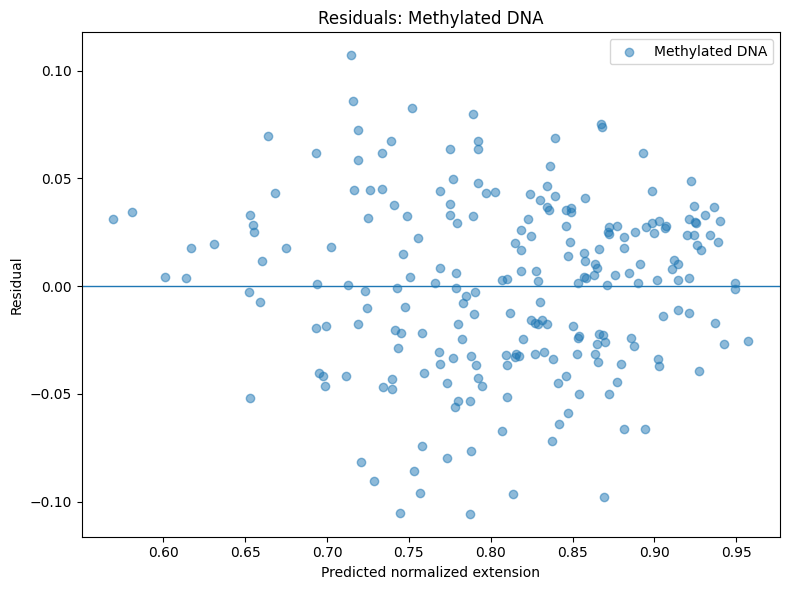

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    mPCR_clean["predicted_extension"],
    mPCR_clean["residual"],
    alpha=0.5,
    label="Methylated DNA"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Predicted normalized extension")
plt.ylabel("Residual")
plt.title("Residuals: Methylated DNA")
plt.legend()

plt.tight_layout()
plt.show()

### Diagnostic Interpretation

Residuals for both datasets are centered close to zero and show no strong systematic curvature across the fitted range, supporting use of the linearized WLC approximation for these representative measurements.

The methylated DNA dataset shows somewhat greater residual variability than the control dataset, consistent with its lower \(R^2\) value. Some structure and variation in residual spread remain, indicating that the linear approximation does not capture all experimental variability.

Overall, the diagnostic results support use of the linearized model for estimating and comparing persistence length in these datasets while also illustrating the limitations of a simplified model of experimental force–extension behavior.


## 6. Exploratory Classification of Mechanical States

The WLC analysis demonstrates that the representative control and methylated DNA datasets differ in their mechanical behavior. As an exploratory computational extension, a simple classification model is used to examine whether individual force–extension observations from these two datasets can be distinguished based on their mechanical features.

Each observation is represented by two features:

* normalized extension (\(Z/L\))
* inverse square root of force (\(F^{-1/2}\))

The objective is to classify observations as originating from the control or methylated DNA dataset.

Because the observations analyzed here originate from only two representative experiments, individual force–extension points are not independent biological replicates. The classification analysis therefore evaluates separation within these datasets and should not be interpreted as evidence that the model can predict methylation status in independent DNA molecules or experiments.


In [15]:
# Combine cleaned datasets and assign condition labels

control_ml = cPCR_clean[
    ["normalized_extension", "inv_sqrt_force"]
].copy()

control_ml["condition"] = 0

methylated_ml = mPCR_clean[
    ["normalized_extension", "inv_sqrt_force"]
].copy()

methylated_ml["condition"] = 1

classification_data = pd.concat(
    [control_ml, methylated_ml],
    ignore_index=True
)

print("Classification dataset shape:", classification_data.shape)
print("\nObservations by condition:")
print(
    classification_data["condition"]
    .value_counts()
    .rename(index={0: "Control DNA", 1: "Methylated DNA"})
)

display(classification_data.head())

Classification dataset shape: (483, 3)

Observations by condition:
condition
Control DNA       255
Methylated DNA    228
Name: count, dtype: int64


,normalized_extension,inv_sqrt_force,condition
0,0.952355,0.451676,0
1,0.923634,0.509886,0
2,0.899607,0.653958,0
3,0.915279,0.851072,0
4,0.895834,0.956380,0


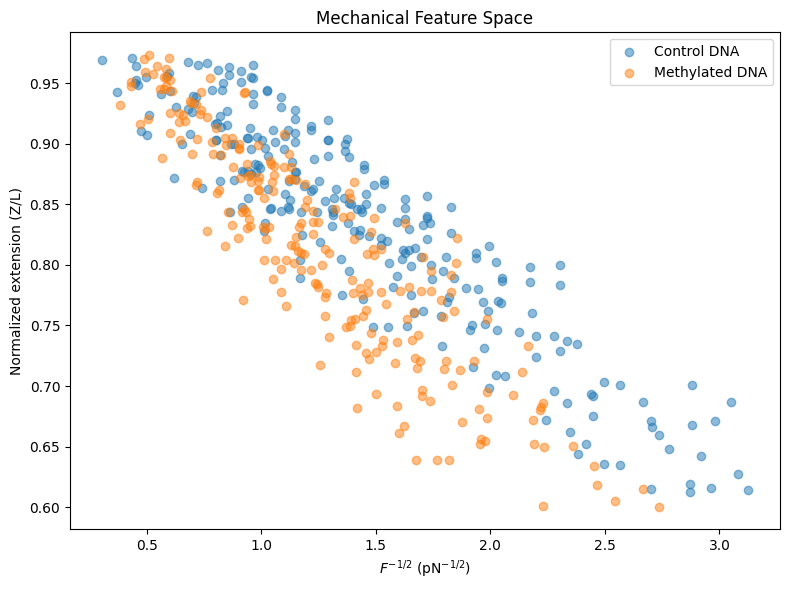

In [16]:
# Visualize the mechanical feature space

plt.figure(figsize=(8, 6))

plt.scatter(
    cPCR_clean["inv_sqrt_force"],
    cPCR_clean["normalized_extension"],
    alpha=0.5,
    label="Control DNA"
)

plt.scatter(
    mPCR_clean["inv_sqrt_force"],
    mPCR_clean["normalized_extension"],
    alpha=0.5,
    label="Methylated DNA"
)

plt.xlabel(r"$F^{-1/2}$ (pN$^{-1/2}$)")
plt.ylabel("Normalized extension (Z/L)")
plt.title("Mechanical Feature Space")

plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Define features and target

X = classification_data[
    ["normalized_extension", "inv_sqrt_force"]
]

y = classification_data["condition"]

# Stratified split preserves the class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training observations: 362
Test observations: 121

Training class distribution:
condition
0    191
1    171
Name: count, dtype: int64

Test class distribution:
condition
0    64
1    57
Name: count, dtype: int64


In [18]:
# Majority-class baseline

majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Majority-class baseline accuracy: {baseline_accuracy:.3f}")

Majority-class baseline accuracy: 0.529


In [19]:
# Standardized logistic-regression classifier

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42))
])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Performance")
print(f"Accuracy:          {accuracy:.3f}")
print(f"Balanced accuracy: {balanced_accuracy:.3f}")
print(f"ROC-AUC:           {roc_auc:.3f}")

Logistic Regression Performance
Accuracy:          0.694
Balanced accuracy: 0.696
ROC-AUC:           0.806


In [20]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Control", "Actual Methylated"],
    columns=["Predicted Control", "Predicted Methylated"]
)

display(cm_df)

,Predicted Control,Predicted Methylated
Actual Control,43,21
Actual Methylated,16,41


In [21]:
# Precision, recall, and F1 score by condition

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Control DNA", "Methylated DNA"],
        digits=3
    )
)

                precision    recall  f1-score   support

   Control DNA      0.729     0.672     0.699        64
Methylated DNA      0.661     0.719     0.689        57

      accuracy                          0.694       121
     macro avg      0.695     0.696     0.694       121
  weighted avg      0.697     0.694     0.694       121



In [22]:
# Examine standardized logistic-regression coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model
        .named_steps["classifier"]
        .coef_[0]
})

coefficients["Absolute_coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_coefficient",
    ascending=False
)

display(coefficients)

,Feature,Coefficient,Absolute_coefficient
1,inv_sqrt_force,-2.570620,2.570620
0,normalized_extension,-2.407643,2.407643


### Classification Interpretation

The logistic-regression model achieved an accuracy of 0.694 and a balanced accuracy of 0.696 on the held-out test observations, compared with a majority-class baseline of approximately 0.53. The ROC-AUC of 0.806 indicates meaningful, although incomplete, separation between observations from the representative control and methylated DNA datasets.

Classification performance was relatively balanced between the two conditions. Recall was 0.672 for control DNA and 0.719 for methylated DNA, indicating that the model did not achieve its performance simply by favoring one class.

Both normalized extension and \(F^{-1/2}\) contributed substantially to the classifier. Because these variables are mechanically related through the force–extension relationship, their logistic-regression coefficients should be interpreted jointly rather than as independent biological effects. The classifier therefore provides a data-driven complement to the WLC analysis, showing that differences between the two experimental force–extension relationships are detectable in the combined mechanical feature space.

Importantly, the observations originate from only two representative experiments and individual force–extension points are not independent biological replicates. The reported test performance therefore measures within-dataset separability and does not establish generalization to independent molecules, experiments, or methylation states.


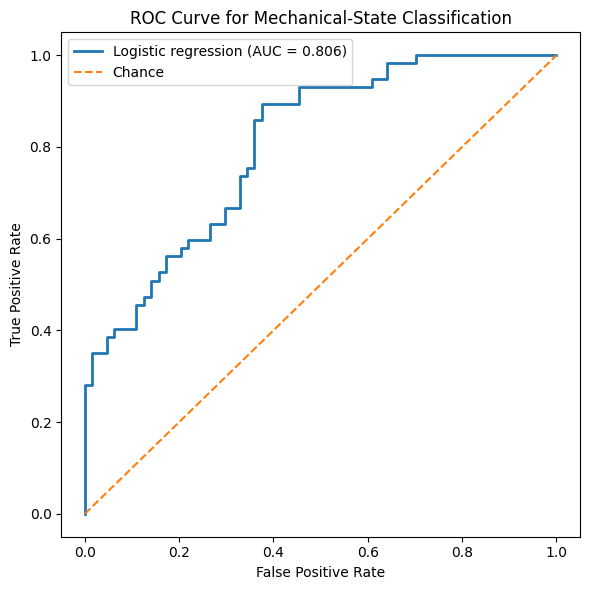

In [23]:
# Plot ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Mechanical-State Classification")
plt.legend()

plt.tight_layout()
plt.show()

## 7. Conclusions

Analysis of two representative single-molecule force–extension datasets identified a clear difference in the mechanical behavior of control and fully methylated DNA.

The WLC-derived analysis estimated persistence lengths of 61.4 nm for control DNA and 37.9 nm for methylated DNA, corresponding to an approximately 38% decrease in the representative methylated dataset and indicating increased DNA flexibility.

An exploratory logistic-regression analysis provided a complementary data-driven perspective. Using normalized extension and \(F^{-1/2}\), the classifier achieved a ROC-AUC of 0.806 and an accuracy of 0.694 compared with a majority-class baseline of 0.529, demonstrating partial separation of the two mechanical states within these datasets.

Together, the physics-based and exploratory computational analyses show that methylation-associated differences are detectable in the force–extension behavior of these representative experiments. Because the notebook analyzes two processed representative datasets rather than independent experimental replicates, the numerical estimates and classification performance should be interpreted as dataset-specific rather than as population-level estimates.
